# Analysis of Immunotherapy Resistance in Melanoma
Author: Miguel Rosell Hidalgo 
Date: February of 2026  
Context: Precision Oncology / Transcriptomics Case Study

## 1. Abstract
This project simulates and analyzes bulk RNA-seq data from 100 melanoma patients undergoing immunotherapy. The .csv is randomly generated to identify molecular subtypes driving treatment resistance using unsupervised Dimensionality Reduction techniques (in this case, PCA). The analysis navigates through quality control, data normalization strategies, and biological interpretation of latent variables (Principal Components).

## 2. Study Design
Cohort: 100 Patients.
Features: 50 Genes (First 20 genes are proliferation markers, the 20 next are Immune markers, and the last 10 are Housekeeping genes).
My goal is to decouple technical noise from biological signals to predict responders vs. non-responders and maybe be able to explain why patients are not responding adequatly to treatment. 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# REPRODUCIBILITY SETUP 
# Setting the seed ensures the random numbers are identical every time this code is run.
np.random.seed(42)

# DATA SIMULATION 
n_patients = 100
n_genes = 50
gene_names = [f"Gene_{i+1:02d}" for i in range(n_genes)]

# Defining latent biological groups (Ground Truth)
# Group A: High immune, low proliferation (Responders)
# Group B: Low immune, high proliferation (Resistant)
# Group C: Low immune, low proliferation (Cold/quiet)
group_A = np.random.normal(loc=[2, 8, 2], scale=1.5, size=(30, 3))
group_B = np.random.normal(loc=[8, 2, 2], scale=1.5, size=(40, 3))
group_C = np.random.normal(loc=[3, 3, 2], scale=1.0, size=(30, 3))
latent_structure = np.vstack([group_A, group_B, group_C])

# Here, we define the gene weights (Loadings)
# Dims: [Proliferation, Immunity, Housekeeping]
weights = np.zeros((3, n_genes))
weights[0, 0:20] = np.random.uniform(0.8, 1.2, 20)   # Prolif genes (1-20)
weights[1, 20:40] = np.random.uniform(0.8, 1.2, 20)  # Immune genes (21-40)
weights[2, 40:50] = np.random.uniform(0.5, 1.5, 10)  # Housekeeping (41-50)

# Generating counts (Exponential nature of RNA-seq)
base_data = np.dot(latent_structure, weights)
counts_data = np.exp(base_data)

# Adding technical artifacts (Outliers)
# Simulating sequencing errors in specific samples to test QC pipeline
counts_data[99, :] = counts_data[99, :] * 50  # The "Bill Gates" effect
# Note: Other outliers might arise naturally due to exponential scaling, therefore what does this indicate? We might need to log these data!

# Final dataset construction
raw_counts = np.round(counts_data).astype(int) + 1
df = pd.DataFrame(raw_counts, columns=gene_names)
df['Patient_ID'] = [f"P{i+1:03d}" for i in range(n_patients)]

print(f"Dataset generated: {df.shape[0]} Patients x {df.shape[1]-1} Genes")

Dataset Generated: 100 Patients x 50 Genes


## 3. Quality control (QC) & exploratory data analysis

Before applying dimensionality reduction, we must assess the data distribution and identify technical artifacts.

Initial strategy:
1.  Perform a "Dirty PCA" on raw counts to detect outliers.
2.  Visualize the projection to understand the data geometry.

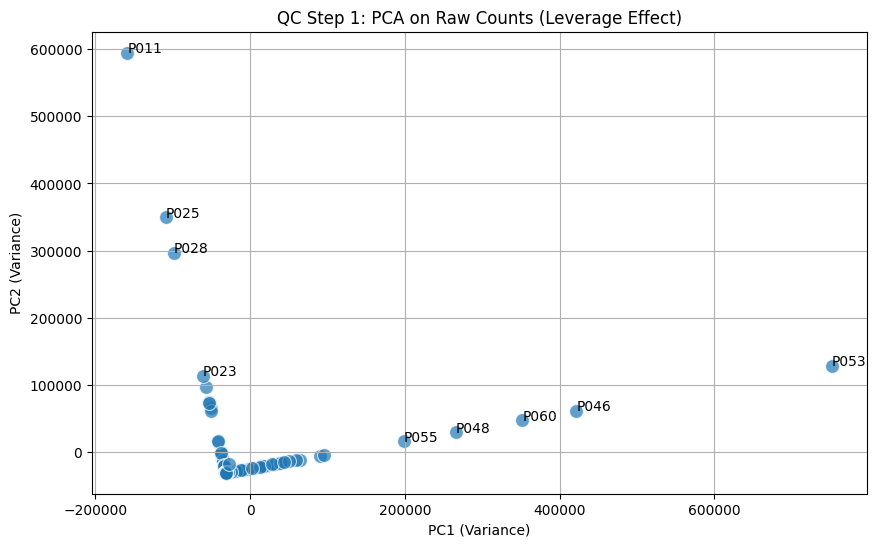

In [ ]:
# Preparing data (Dropping IDs for numerical computation)
X_raw = df.drop('Patient_ID', axis=1)

# Initial PCA on raw data
pca_raw = PCA(n_components=2)
coords_raw = pca_raw.fit_transform(X_raw)

# Visualization
plt.figure(figsize=(10, 6))
sns.scatterplot(x=coords_raw[:,0], y=coords_raw[:,1], s=100, alpha=0.7)

# Labeling points to identify the outlier
for i in range(len(coords_raw)):
    # We only label points that are far from the origin to avoid clutter
    if coords_raw[i, 0] > 100000 or coords_raw[i, 1] > 100000:
        plt.text(coords_raw[i,0], coords_raw[i,1], df.Patient_ID[i])

plt.title("QC Step 1: PCA on raw counts (Leverage Effect)")
plt.xlabel("PC1 (Variance)")
plt.ylabel("PC2 (Variance)")
plt.grid(True)
plt.show()

### QC Observations & decision

The raw PCA reveals a massive scale distortion (axes reaching ~800,000). A few samples (e.g., P053, P011) are acting as strong outliers, compressing the rest of the cohort into the origin.

Action: Removal of technical outliers identified in the plot.

> Analyst Note: Even after removing 7 outliers, the axes range reduced from 800k to 200k, but the "L-Shape" persists. Iterative removal of patients is inefficient ("whac-a-mole" effect) because the underlying issue is not just the outliers, but the exponential nature of the data distribution. It does not follow a Gaussian (Normal) distribution.

Cohort size after cleaning: 97 patients.


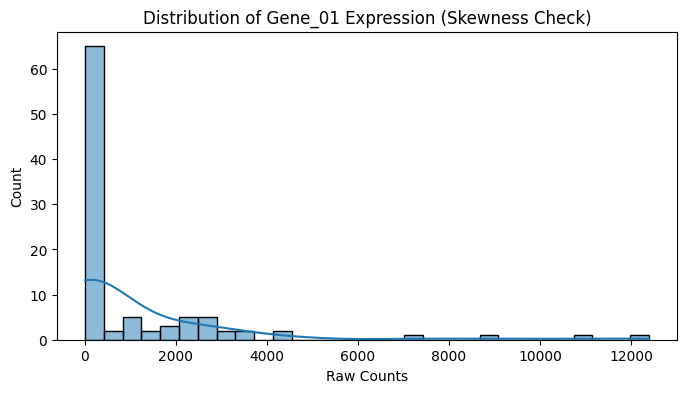

In [ ]:
# 1. Removal of outliers identified in the previous step
# (Adjust IDs based on your specific run, e.g., P053, P011, P100...)
outliers = ['P053', 'P011', 'P100'] 
df_clean = df[~df['Patient_ID'].isin(outliers)].copy()

print(f"Cohort size after cleaning: {df_clean.shape[0]} patients.")

# 2. Distribution check (Histogram)
# Testing the hypothesis of non-normal distribution on a random gene (Gene_01)
plt.figure(figsize=(8, 4))
sns.histplot(df_clean['Gene_01'], bins=30, kde=True)
plt.title("Distribution of Gene_01 expression (Skewness check)")
plt.xlabel("Raw Counts")
plt.show()

## 4. Normalization and final PCA

The histogram confirms a highly skewed distribution (long tail). PCA assumes linear correlations, which break down with exponential data.

Strategy:
1.  Log-Transformation (`log(x+1)`): To linearize the biological signal and compress the monumental range (200k) to a logical scale (~10).
2.  Z-Score Standardization (Scaling): To ensure all genes contribute equally to variance, regardless of their absolute expression levels.

Variance Explained by PC1: 66.2%
Variance Explained by PC2: 19.1%
Total Variance (PC1+PC2): 85.3%


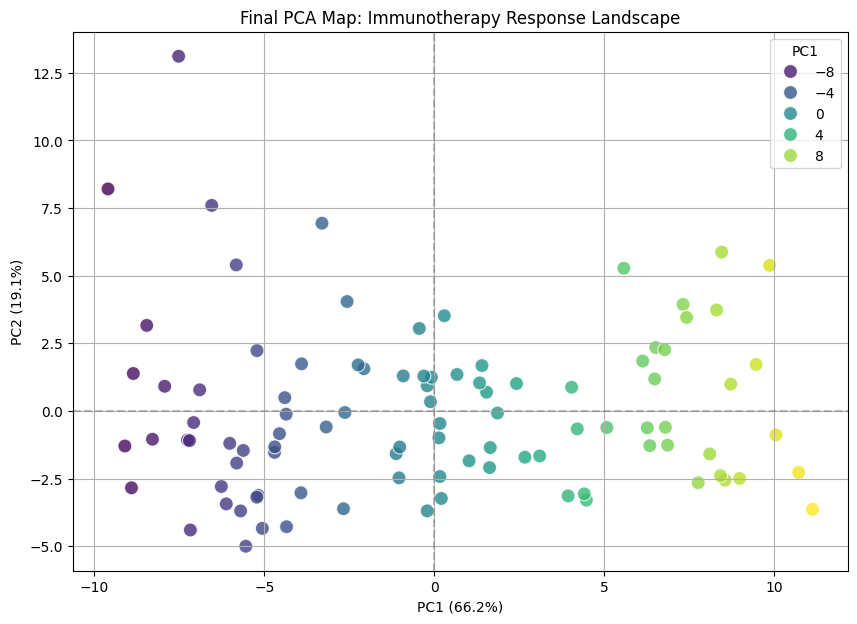

In [ ]:
# 1. Log-Transformation
X_log = np.log1p(df_clean.drop('Patient_ID', axis=1))

# 2. Standardization (Z-Score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 3. Final PCA
pca_final = PCA(n_components=50)
coords_final = pca_final.fit_transform(X_scaled)

# Creating a DataFrame for the final plot
df_pca = pd.DataFrame(coords_final[:, 0:2], columns=['PC1', 'PC2'])
df_pca['Patient_ID'] = df_clean['Patient_ID'].values

# Variance explained
var_exp = pca_final.explained_variance_ratio_
print(f"Variance Explained by PC1: {var_exp[0]*100:.1f}%")
print(f"Variance Explained by PC2: {var_exp[1]*100:.1f}%")
print(f"Total Variance (PC1+PC2): {sum(var_exp[0:2])*100:.1f}%")

# Plotting
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=df_pca, s=100, alpha=0.8, hue='PC1', palette='viridis')
plt.title("Final PCA Map: Immunotherapy Response Landscape")
plt.xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
plt.axvline(0, linestyle='--', color='gray', alpha=0.5)
plt.axhline(0, linestyle='--', color='gray', alpha=0.5)
plt.grid(True)
plt.show()

## 5. Biological interpretation (Loadings)

To decode the biological meaning of the axes, we analyze the loadings (weights) of each gene in PC1 and PC2.

Interpretation logic:
* Origin (0,0): Represents the "Average patient".
* (-PC1, -PC2): Patients with lower-than-average expression of genes with positive weights.
* (+PC1): Patients driving the variance defined by positive-weight genes.

Findings:
1.  PC1 (The biological axis): positive weights: Driven by Proliferation genes (01-20).
    * Negative Weights: Driven by immune genes (21-40).
    * Conclusion: PC1 separates "cold/proliferative tumors" (right) from "hot/immune tumors" (left).
2.  PC2 (The technical/noise axis):
    * Positive Weights: Driven by housekeeping genes (41-50).
    * Patients with negative PC2 values appear there not due to negative weights, but due to low expression of these housekeeping genes relative to the mean.

C:\Users\migue\AppData\Local\Temp\ipykernel_21660\155291149.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pc1.values, y=top_pc1.index, palette='coolwarm')
C:\Users\migue\AppData\Local\Temp\ipykernel_21660\155291149.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_pc2.values, y=top_pc2.index, palette='coolwarm')


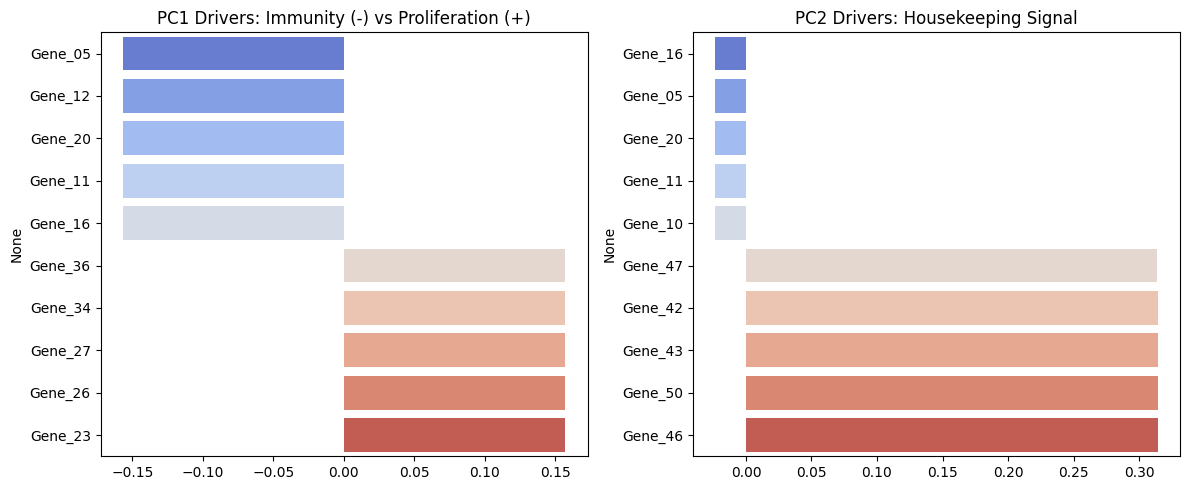

In [ ]:
# Extracting loadings
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(50)], 
    index=df.columns[:-1]
)

# Visualizing top drivers
plt.figure(figsize=(12, 5))

# PC1 drivers
plt.subplot(1, 2, 1)
sorted_pc1 = loadings['PC1'].sort_values()
top_pc1 = pd.concat([sorted_pc1.head(5), sorted_pc1.tail(5)])
sns.barplot(x=top_pc1.values, y=top_pc1.index, palette='coolwarm')
plt.title("PC1 Drivers: Immunity (-) vs Proliferation (+)")

# PC2 drivers
plt.subplot(1, 2, 2)
sorted_pc2 = loadings['PC2'].sort_values()
top_pc2 = pd.concat([sorted_pc2.head(5), sorted_pc2.tail(5)])
sns.barplot(x=top_pc2.values, y=top_pc2.index, palette='coolwarm')
plt.title("PC2 Drivers: Housekeeping Signal")

plt.tight_layout()
plt.show()

## 6. Clinical conclusion

The unsupervised analysis identified three distinct patient clusters based on their transcriptomic profiles:

1. The "responders" (PC1 negative / left): characterized by high expression of T-cell immune markers and low tumor proliferation. These patients ("Hot Tumors") are the ideal candidates for immunotherapy.
2. The "Resistant/Cold" (PC1 Positive / Right): characterized by high proliferation and lack of immune infiltration. Immunotherapy is likely to fail; alternative treatments targeting cell cycle (e.g., CDK4/6 inhibitors) should be considered.
3. The "high-noise" group (PC2 High): characterized by aberrant overexpression of housekeeping genes, suggesting potential quality issues or high metabolic activity, but biologically aligned with the resistant phenotype.

The recommendation based on the findings of this PCA would then be to stratify patients based on PC1 score < 0 for clinical trial inclusion.